### 📊 Dataset Column Descriptions
* credit.policy: Indicates whether the borrower meets the credit underwriting criteria of LendingClub.
#### (1 = meets criteria, 0 = does not meet criteria)

* purpose: The reason for the loan. Possible values include:
* credit_card, debt_consolidation, educational, major_purchase, small_business, all_other
* int.rate: The interest rate of the loan expressed as a decimal.
##### (e.g., 11% is represented as 0.11)
* Higher rates typically indicate higher risk borrowers.
* installment: The fixed monthly payment the borrower must make if the loan is approved.
* log.annual.inc: The natural logarithm of the borrower’s self-reported annual income.
* dti: Debt-to-Income ratio — the proportion of a borrower’s debt relative to their annual income.
* fico: The borrower’s credit score, provided by FICO, used to assess creditworthiness.
* days.with.cr.line: Total number of days the borrower has had an active credit line.
* revol.bal: The borrower’s outstanding revolving balance (e.g., unpaid credit card balance).
* revol.util: Revolving utilization rate — the percentage of available credit currently being used.
* inq.last.6mths: Number of credit inquiries made by lenders in the past 6 months.
* delinq.2yrs: Number of times the borrower was over 30 days late on payments in the past 2 years.
* pub.rec: Number of negative public records such as bankruptcies, tax liens, or legal judgments.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Get the Data

In [2]:
loans = pd.read_csv('loan_data.csv')

#### Check out the info(), head(), and describe() methods on loans.

In [3]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
loans.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [5]:

loans.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Exploratory Data Analysis
* Let's do some data visualization! We'll use seaborn and pandas built-in plotting capabilities, but feel free to use whatever library you want. Don't worry about the colors matching, just worry about getting the main idea of the plot.

* Create a histogram of two FICO distributions on top of each other, one for each credit.policy outcome.

Text(0.5, 0, 'FICO')

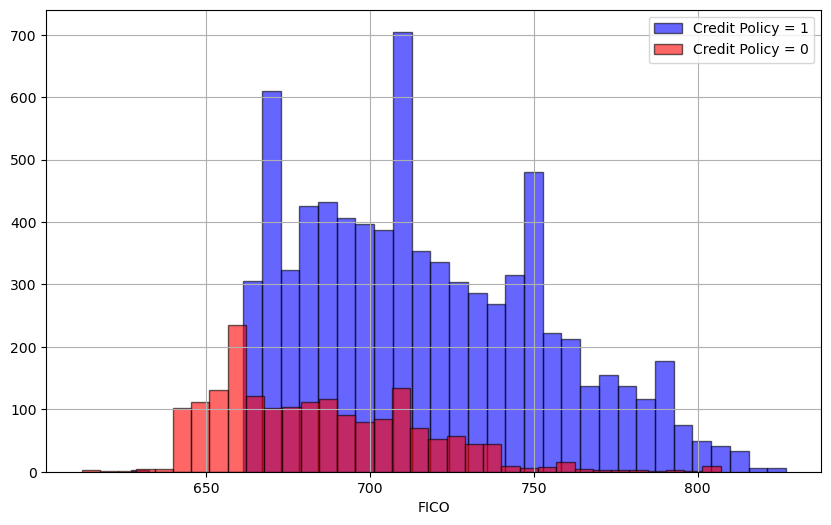

In [6]:
plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(bins=35,color='blue',edgecolor='black',label='Credit Policy = 1',alpha=0.6)
loans[loans['credit.policy']==0]['fico'].hist(bins=35,color='red',edgecolor='black',label='Credit Policy = 0',alpha=0.6)
plt.legend()
plt.xlabel('FICO')

This histogram compares FICO score distributions for two groups:

Blue (Credit Policy = 1) → applicants who meet the credit policy
Red (Credit Policy = 0) → applicants who do not meet the policy
What the chart shows

1. Clear separation in score ranges

The blue distribution is shifted to the right → generally higher FICO scores
The red distribution is concentrated to the left → generally lower FICO scores

2. Typical score bands

Credit Policy = 1: mostly around 680–780, with many above 700
Credit Policy = 0: mostly around 640–700, with fewer high-score borrowers

3. Overlap region

There’s noticeable overlap between roughly 660–720
This suggests FICO alone isn’t the only decision factor—other variables likely influence approval

4. Tails

Very high scores (800+) are almost exclusively in the approved group
Very low scores (<640) are almost entirely in the rejected group

Text(0.5, 0, 'FICO')

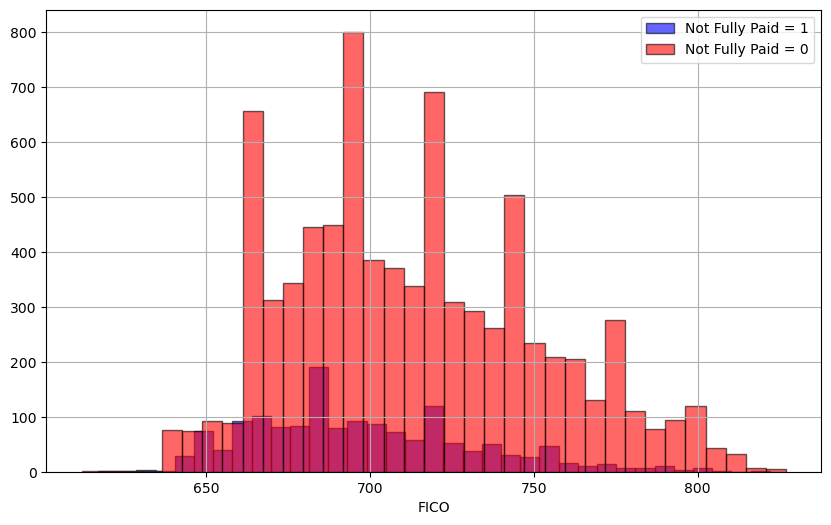

In [7]:
plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==1]['fico'].hist(bins=35,color='blue',edgecolor='black',label='Not Fully Paid = 1',alpha=0.6)
loans[loans['not.fully.paid']==0]['fico'].hist(bins=35,color='red',edgecolor='black',label='Not Fully Paid = 0',alpha=0.6)
plt.legend()
plt.xlabel('FICO')

This second histogram compares FICO scores vs repayment outcome:

Blue (Not Fully Paid = 1) → borrowers who defaulted / didn’t fully repay
Red (Not Fully Paid = 0) → borrowers who successfully repaid
What stands out

1. Separation is weaker than the credit policy plot

Unlike your previous chart, these two distributions overlap heavily
This means FICO is less predictive of repayment than it is of approval decisions

2. General trend still exists

Defaults (blue) skew slightly toward lower FICO scores (≈650–710)
Fully paid loans (red) are more common at higher scores (≈700–780+)

3. But high-score defaults do exist

You still see blue bars even in the 750–800 range
So a high FICO reduces risk but doesn’t eliminate it

4. Low-score successful repayments also exist

Some borrowers with lower FICO (~650–680) still repay fully
Suggests other factors (income, loan purpose, debt ratio, etc.) matter a lot
Key takeaway

FICO score is directionally useful but not decisive for predicting default:

Good for risk stratification
Not sufficient as a standalone predictor
Comparing both charts (important insight)
Credit policy vs FICO → strong separation (decision rule)
Default vs FICO → weak separation (real-world outcome)

👉 This implies the policy is based on FICO, but FICO alone doesn’t fully capture repayment risk.

### Create a countplot using seaborn showing the counts of loans by purpose, with the color hue defined by not.fully.paid.

<AxesSubplot:xlabel='purpose', ylabel='count'>

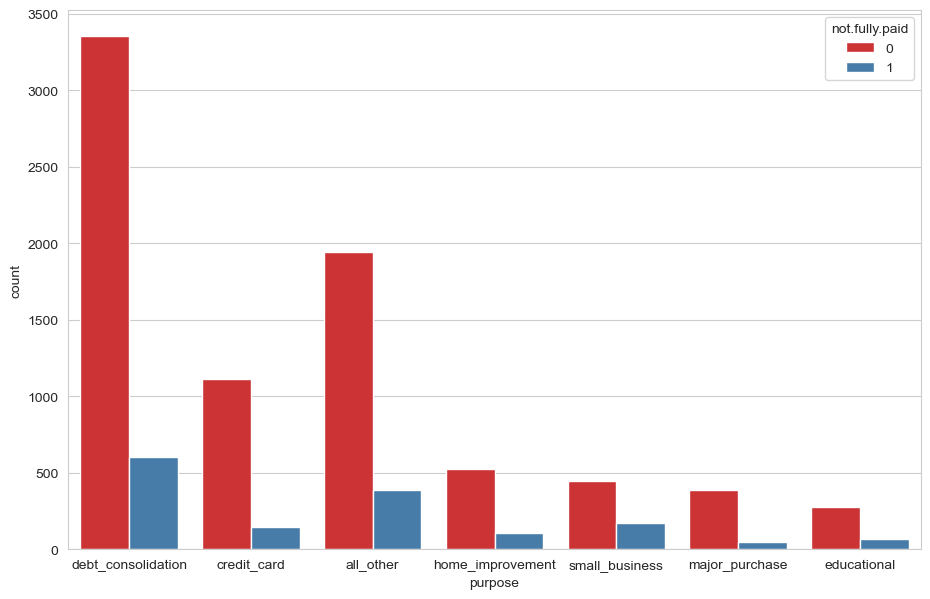

In [8]:
plt.figure(figsize=(11,7))
sns.set_style('whitegrid')
sns.countplot(x='purpose',hue='not.fully.paid',data=loans,palette='Set1')

This bar chart shows how loan purpose relates to repayment outcomes (whether a loan was fully paid or not).

Red (0) → Fully paid
Blue (1) → Not fully paid (default)
What stands out

1. Volume is heavily skewed

Debt consolidation dominates by a large margin
Followed by all_other and credit_card
Smaller categories: small_business, home_improvement, major_purchase, educational

👉 So any overall default trend will be strongly influenced by debt consolidation loans

2. Default risk varies by purpose (this is the key insight)

Looking at the relative blue vs red bars:

Higher relative default risk:
Small business → noticeably higher proportion of defaults
Educational → also relatively high default share
These categories have fewer loans but riskier profiles
Moderate risk:
Debt consolidation → large number of defaults, but also huge volume
All_other → similar pattern
Lower relative default risk:
Credit card
Home improvement
Major purchase

👉 These categories show smaller blue-to-red ratios, suggesting better repayment behavior

Important nuance

Don’t confuse:

Total defaults (counts) vs
Default rate (proportion)

For example:

Debt consolidation has the most defaults, but that's partly because it has the most loans
Small business has fewer loans but a higher risk per loan
Key takeaway

Loan purpose is a meaningful predictor of default risk:

Some purposes (like small business) are inherently riskier
Others (like home improvement or credit card refinancing) tend to be safer

#### Let's see the trend between FICO score and interest rate. Recreate the following jointplot.

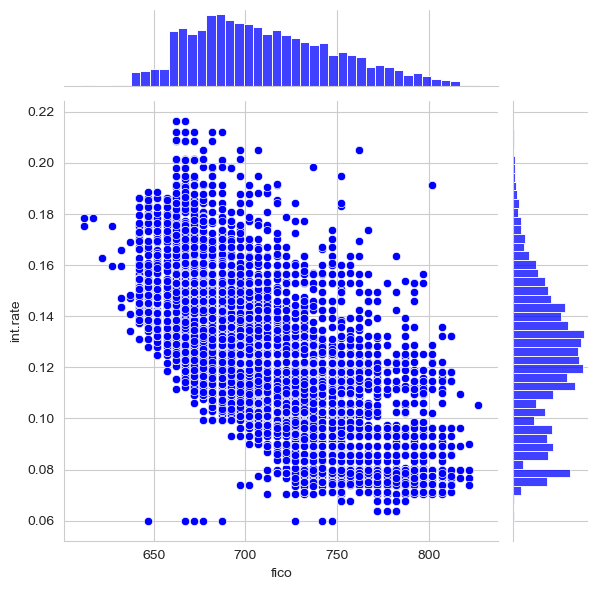

In [9]:
sns.jointplot(x='fico',y='int.rate',data=loans,color='blue')

What it tells us
1. Strong negative relationship


As FICO scores increase, interest rates generally decrease.


Borrowers with lower credit scores (~640–680) tend to have higher rates (~0.14–0.20).


Borrowers with higher scores (~750–800+) tend to cluster at lower rates (~0.07–0.12).


2. Nonlinear spread


The relationship isn’t perfectly linear:


At lower FICO ranges, interest rates are more spread out (higher variability).


At higher FICO ranges, rates compress into a tighter band.




3. Diminishing returns


Improvements in FICO at the lower end (e.g., 650 → 700) yield a bigger drop in rates than improvements at the high end (e.g., 750 → 800).


4. Marginal distributions


Top histogram (FICO): Most borrowers fall roughly between 650 and 780.


Right histogram (interest rate): Heavily concentrated between ~0.08 and 0.14.


5. Outliers


A few borrowers with relatively high FICO still have higher rates—likely due to other risk factors (loan purpose, income, debt ratio, etc.).


Similarly, some low-rate loans appear even for mid-range FICO scores.


Bottom line
Credit score is a major driver of interest rate, but not the only one. The plot clearly shows lenders price risk based on creditworthiness, with higher scores earning lower borrowing costs—though other variables still influence the final rate.


#### Let's create the following lmplots to see if the trend differed between not.fully.paid and credit.policy.

<Figure size 1100x700 with 0 Axes>

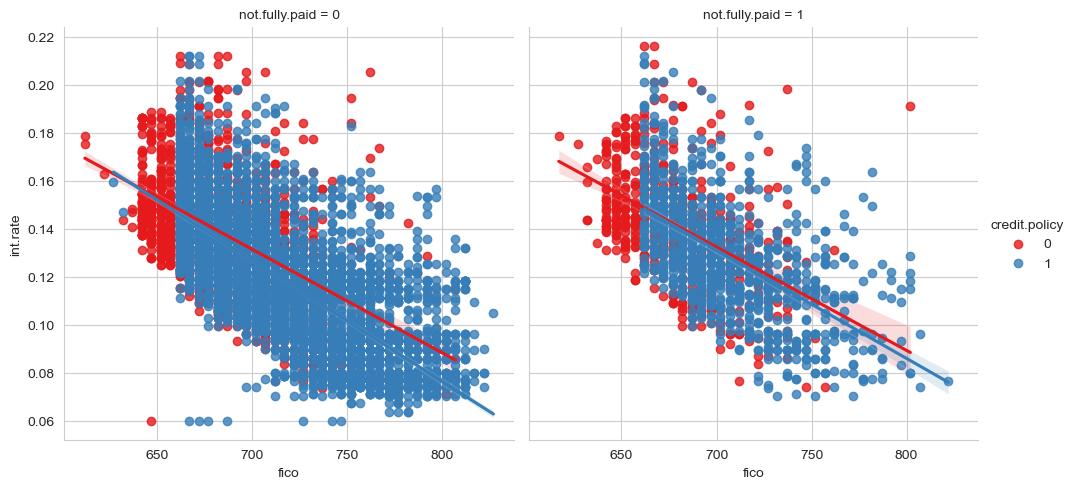

In [10]:
plt.figure(figsize=(11,7))
sns.lmplot(y='int.rate',x='fico',data=loans,hue='credit.policy',col='not.fully.paid',palette='Set1')

Here’s what’s going on:

1. The negative relationship still holds in both groups
In both panels, higher FICO → lower interest rate.
The downward regression lines confirm this consistency regardless of repayment outcome.
2. Loans that weren’t fully paid show slightly higher rates
In the not.fully_paid = 1 panel (right), points tend to sit a bit higher on the y-axis.
That suggests these loans were priced with higher risk premiums from the start.
3. Credit policy separation is visible
Red (credit_policy = 0): Loans that didn’t meet stricter credit criteria.
Clustered more at lower FICO + higher rates.
Blue (credit_policy = 1): Loans meeting policy standards.
More common at higher FICO + lower rates.

This shows the policy is doing what you’d expect: filtering toward stronger borrowers.

4. Overlap explains why defaults still happen
There’s substantial overlap between red and blue, especially in mid FICO ranges (~680–740).
Even among higher-quality borrowers (blue), some loans still end up not fully paid.
So, FICO + policy isn’t enough to perfectly predict outcomes.
5. Slope differences hint at risk sensitivity
The slope for policy-approved loans (blue) appears slightly steeper:
Interest rates drop more sharply with increasing FICO.
This suggests lenders differentiate pricing more aggressively within “approved” borrowers.
Bottom line
FICO score strongly influences pricing, regardless of outcome.
Credit policy filters risk, but not perfectly.
Higher interest rates correlate with higher default risk, but there’s no clean cutoff—risk is continuous and overlapping.

## Setting up the Data
#### Let's get ready to set up our data for our Random Forest Classification Model!

#### Check loans.info() again.

In [11]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


## Categorical Features
#### Notice that the purpose column as categorical

#### That means we need to transform them using dummy variables so sklearn will be able to understand them. Let's do this in one clean step using pd.get_dummies.

#### Create a list of 1 element containing the string 'purpose'. Call this list cat_feats.

In [12]:
cat_feats = ['purpose']

#### Now use pd.get_dummies(loans,columns=cat_feats,drop_first=True) to create a fixed larger dataframe that has new feature columns with dummy variables. Set this dataframe as final_data.

In [13]:
final_data = pd.get_dummies(loans,columns=cat_feats,drop_first=True)

In [14]:
final_data.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0,1,0,0,0,0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1,0,0,0,0,0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0,1,0,0,0,0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0,1,0,0,0,0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1,0,0,0,0,0


## Train Test Split
#### Now its time to split our data into a training set and a testing set!

#### Use sklearn to split your data into a training set and a testing set as we've done in the past.

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X = final_data.drop('not.fully.paid',axis=1)
y = final_data['not.fully.paid']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=101)

## Training a Decision Tree Model
#### Let's start by training a single decision tree first!

#### Import DecisionTreeClassifier

In [17]:
from sklearn.tree import DecisionTreeClassifier

### Create an instance of DecisionTreeClassifier() called dtree and fit it to the training data.

In [18]:
dtree = DecisionTreeClassifier()

In [19]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

## Predictions and Evaluation of Decision Tree
### Create predictions from the test set and create a classification report and a confusion matrix.

In [20]:
predictons = dtree.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

In [22]:
print(classification_report(y_test,predictons))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      2666
           1       0.18      0.23      0.20       495

    accuracy                           0.72      3161
   macro avg       0.52      0.52      0.52      3161
weighted avg       0.75      0.72      0.73      3161



In [23]:
print(confusion_matrix(y_test,predictons))

[[2162  504]
 [ 381  114]]


## Training the Random Forest model
### Now its time to train our model!

#### Create an instance of the RandomForestClassifier class and fit it to our training data from the previous step.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier(n_estimators=300)

In [ ]:
rfc.fit(X_train,y_train)

## Predictions and Evaluation
### Let's predict off the y_test values and evaluate our model.

### Predict the class of not.fully.paid for the X_test data.

In [ ]:
predictons = rfc.predict(X_test)

#### Now create a classification report from the results. Do you get anything strange or some sort of warning?

In [ ]:
print(classification_report(y_test,predictons))

#### Show the Confusion Matrix for the predictions.

In [ ]:
print(confusion_matrix(y_test,predictons))